In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt

In [ ]:
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [ ]:
import gradio as gr

In [ ]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
data1 = pd.read_csv("/content/archive.zip")
data2 = pd.read_csv("/content/Dataset-SA.csv.zip")

In [ ]:
data1 = data1.rename(columns={
    'reviews.text': 'review',
    'reviews.rating': 'rating'
})

data2 = data2.rename(columns={
    'Review': 'review',
    'Sentiment': 'sentiment'
})


In [ ]:
data1 = data1.dropna(subset=['review', 'rating'])
data1['sentiment'] = data1['rating'].apply(lambda x: 'positive' if x >= 4 else 'negative')

data2 = data2.dropna(subset=['review', 'sentiment'])


In [ ]:
data = pd.concat([
    data1[['review', 'sentiment']],
    data2[['review', 'sentiment']]
], ignore_index=True)

In [ ]:
data.drop_duplicates(subset='review', inplace=True)

In [ ]:
data['sentiment'] = data['sentiment'].str.strip().str.lower()
data = data[data['sentiment'] != 'neutral']

data['sentiment'] = data['sentiment'].map({
    'positive': 'Positive',
    'negative': 'Negative'
})


In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)  # remove links
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [w for w in words if w not in stop_words and len(w) > 2]
    return " ".join(words)

data['clean_review'] = data['review'].apply(clean_text)
data = data[data['clean_review'].str.len() > 3]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    data['clean_review'],
    data['sentiment'],
    test_size=0.2,
    random_state=42,
    stratify=data['sentiment']
)

In [ ]:
model = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1,2),
        max_df=0.85,
        min_df=3,
        sublinear_tf=True,
        max_features=5000
    )),
    ('clf', MultinomialNB(alpha=0.3))
])


In [ ]:
model.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.85, max_features=5000, min_df=3,
                                 ngram_range=(1, 2), sublinear_tf=True)),
                ('clf', MultinomialNB(alpha=0.3))])

In [ ]:
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, pos_label='Positive')
rec = recall_score(y_test, y_pred, pos_label='Positive')
f1 = f1_score(y_test, y_pred, pos_label='Positive')


In [ ]:
print("\nAccuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1 Score:", f1)


Accuracy: 0.8541666666666666
Precision: 0.855036855036855
Recall: 0.9886363636363636
F1 Score: 0.9169960474308301


<Figure size 640x480 with 0 Axes>

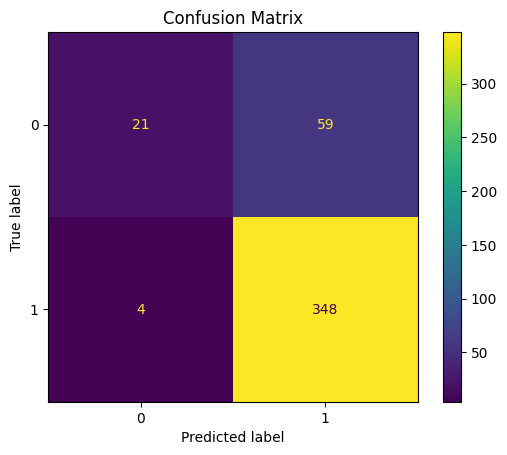

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix")
plt.show()

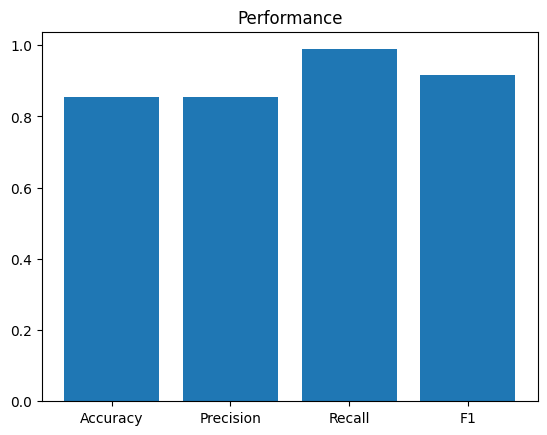

In [ ]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
values = [acc, prec, rec, f1]

plt.figure()
plt.bar(metrics, values)
plt.title("Performance")
plt.show()

In [ ]:
def predict_sentiment(text):
    if text.strip() == "":
        return "⚠️ Please enter a review"

    cleaned = clean_text(text)
    pred = model.predict([cleaned])[0]
    prob = model.predict_proba([cleaned])[0]
    confidence = max(prob)

    emoji = "😊" if pred == "Positive" else "😡"

    return f"{emoji} {pred}\nConfidence: {confidence:.2f}"

def clear_text():
    return ""

with gr.Blocks(
    theme=gr.themes.Soft(
        primary_hue="blue",
        secondary_hue="purple"
    )
) as app:
    # Header
    gr.Markdown(
        """
        # 🧠 Sentiment Analysis System
        ### ✨ Analyze product reviews in real-time
        """
    )

    # Input Section
    with gr.Row():
        with gr.Column(scale=3):
            review_input = gr.Textbox(
                lines=4,
                placeholder="✍️ Enter your product review here...",
                label="Review Input"
            )

        with gr.Column(scale=1):
            predict_btn = gr.Button("🔍 Analyze", variant="primary")
            clear_btn = gr.Button("🧹 Clear", variant="secondary")

    # Output Section
    output = gr.Textbox(
        label="Prediction Result",
        interactive=False
    )

    # Buttons actions
    predict_btn.click(predict_sentiment, inputs=review_input, outputs=output)
    clear_btn.click(clear_text, inputs=None, outputs=review_input)

    # Divider
    gr.Markdown("---")

    # Metrics Section
    gr.Markdown("## 📊 Model Performance")

    with gr.Row():
        gr.Markdown(f"""
        ### 📈 Metrics
        - **Accuracy:** {acc:.2f}
        - **Precision:** {prec:.2f}
        - **Recall:** {rec:.2f}
        - **F1 Score:** {f1:.2f}
        """)

    # Footer
    gr.Markdown(
        """
        ---
        🚀 Built using **Naive Bayes + TF-IDF + Gradio**
        """
    )

app.launch()


with gr.Blocks(theme=gr.themes.Soft()) as app:
    gr.Markdown("## 🧠 Advanced Sentiment Analysis (Naive Bayes)")
    gr.Markdown("Enter a product review below:")

    inp = gr.Textbox(lines=3, placeholder="Type your review...")
    out = gr.Textbox()

    btn = gr.Button("Analyze")

    btn.click(predict_sentiment, inputs=inp, outputs=out)

    gr.Markdown("### 📊 Model Performance")
    gr.Markdown(f"""
    - Accuracy: **{acc:.2f}**
    - Precision: **{prec:.2f}**
    - Recall: **{rec:.2f}**
    - F1 Score: **{f1:.2f}**
    """)
app.launch()

/tmp/ipykernel_7087/534106499.py:17: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://87b56dc9d08eebab6e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


/tmp/ipykernel_7087/534106499.py:80: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as app:


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7bfaa872c248172b0f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
